In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Impostazioni grafiche
sns.set(style="whitegrid")

# Carica il dataset
df = pd.read_csv('../data/raw/college_student_placement_dataset.csv')

# Visualizza le prime righe per controllo
print("Dataset originale:")
display(df.head())

Dataset originale:


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [2]:
# 1. Convertiamo le variabili categoriche in numeriche per poter fare le medie
# 'Yes' diventa 1, 'No' diventa 0
df['Internship_Experience_Numeric'] = df['Internship_Experience'].map({'Yes': 1, 'No': 0})
df['Placement_Numeric'] = df['Placement'].map({'Yes': 1, 'No': 0})

# 2. Raggruppiamo per College_ID e calcoliamo le aggregazioni
# Definiamo come aggregare ogni colonna
agg_funcs = {
    'IQ': 'mean',
    'Prev_Sem_Result': 'mean',
    'CGPA': 'mean',
    'Academic_Performance': 'mean',
    'Extra_Curricular_Score': 'mean',
    'Communication_Skills': 'mean',
    'Projects_Completed': 'mean',
    'Internship_Experience_Numeric': 'mean', # Diventa la % di studenti con internship
    'Placement_Numeric': 'mean',           # Diventa la % di studenti piazzati (Placement Rate)
    'College_ID': 'count'                  # Conta il numero di studenti per college
}

college_df = df.groupby('College_ID').agg(agg_funcs)

# Rinominiamo le colonne per chiarezza
college_df = college_df.rename(columns={
    'Internship_Experience_Numeric': 'Internship_Rate',
    'Placement_Numeric': 'Placement_Rate',
    'College_ID': 'Student_Count'
})

print("Nuovo dataset aggregato per College:")
display(college_df.head())

Nuovo dataset aggregato per College:


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Rate,Placement_Rate,Student_Count
College_ID,,,,,,,,,,
CLG0001,98.522936,7.553761,7.587890,5.486239,4.862385,5.321101,2.091743,0.412844,0.100917,109
CLG0002,101.639535,7.650465,7.627326,5.488372,5.220930,5.476744,2.558140,0.418605,0.139535,86
CLG0003,100.804124,7.601031,7.596598,5.536082,4.670103,5.845361,2.484536,0.422680,0.175258,97
CLG0004,98.857143,7.592967,7.597363,5.791209,5.329670,5.648352,2.505495,0.384615,0.142857,91
CLG0005,100.616071,7.249911,7.243393,5.553571,4.767857,5.642857,2.401786,0.366071,0.151786,112


In [3]:
# Selezioniamo le colonne da usare per il clustering
# Nota: Potresti voler escludere 'Student_Count' se non vuoi raggruppare in base alla dimensione del college
features = [
    'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
    'Extra_Curricular_Score', 'Communication_Skills',
    'Projects_Completed', 'Internship_Rate', 'Placement_Rate'
]

X = college_df[features]

# Standardizzazione (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Creiamo un DataFrame scalato per comodità (opzionale)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=college_df.index)
X_scaled_df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Rate,Placement_Rate
College_ID,,,,,,,,,
CLG0001,-0.611903,0.098340,0.321538,-0.206208,-0.323153,-0.884560,-2.515907,0.301668,-1.737438
CLG0002,1.410328,0.677069,0.557108,-0.198352,0.769522,-0.310947,0.244164,0.414193,-0.706336
CLG0003,0.868265,0.381227,0.373556,-0.022687,-0.909138,1.047567,-0.191411,0.493807,0.247478
CLG0004,-0.395050,0.332968,0.378124,0.916664,1.100910,0.321502,-0.067382,-0.249737,-0.617630
CLG0005,0.746245,-1.720075,-1.736315,0.041706,-0.611230,0.301252,-0.681117,-0.611966,-0.379234
...,...,...,...,...,...,...,...,...,...
CLG0096,0.720087,0.856240,0.772200,0.383730,-0.088467,0.463454,-2.162184,-0.264914,1.771150
CLG0097,0.423594,0.245293,0.136012,-1.996493,1.212652,1.799927,1.745773,-0.993588,0.062153
CLG0098,0.402119,0.316351,0.272701,2.001006,-0.629370,-1.085174,0.548249,2.283181,-0.363341


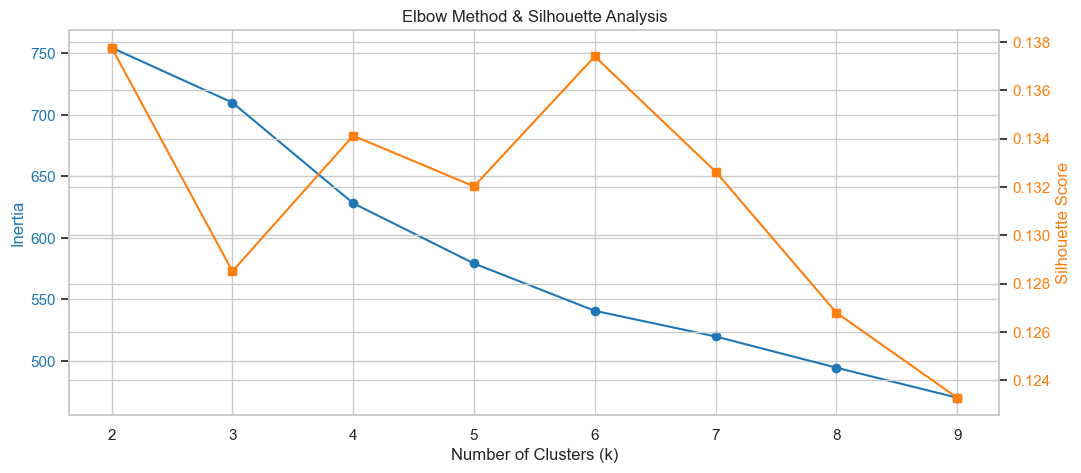

In [4]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow Curve
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(K_range, inertia, color='tab:blue', marker='o', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, color='tab:orange', marker='s', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Elbow Method & Silhouette Analysis')
plt.grid(True)
plt.show()

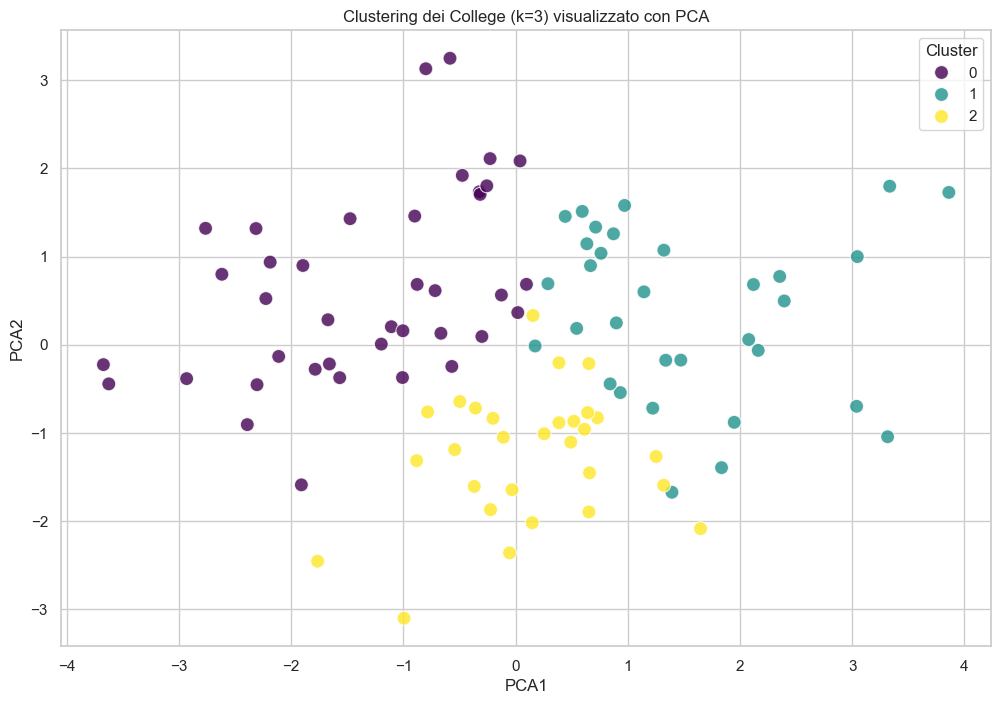

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Rate,Placement_Rate
Cluster,,,,,,,,,
0,99.710793,7.386425,7.380351,5.422844,4.881066,5.621495,2.590149,0.386193,0.164214
1,99.466480,7.689668,7.685763,5.633497,4.943693,5.691166,2.477374,0.401939,0.193582
2,99.136202,7.572172,7.573384,5.602124,5.113192,5.336413,2.461942,0.407464,0.137929


In [ ]:
# 1. Fit del modello (scegliamo k=3 come esempio)
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
college_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Visualizzazione con PCA (Principal Component Analysis)
# Riduciamo le dimensioni da N a 2 per poter fare un grafico a dispersione
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

college_df['PCA1'] = principal_components[:, 0]
college_df['PCA2'] = principal_components[:, 1]

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=college_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title(f'Clustering dei College (k={k_optimal}) visualizzato con PCA')
plt.show()

# Analisi dei cluster: vediamo le caratteristiche medie di ogni gruppo
cluster_analysis = college_df.groupby('Cluster')[features].mean()
display(cluster_analysis)

Numero di studenti anomali rilevati: 0
Percentuale anomalie: 0.00%

Confronto Profili (Medie):


,IQ,CGPA,Projects_Completed,Internship_Binary,Placement_Binary,Communication_Skills
Is_Anomaly,,,,,,
Normale,99.4718,7.532379,2.5134,0.3964,0.1659,5.5618


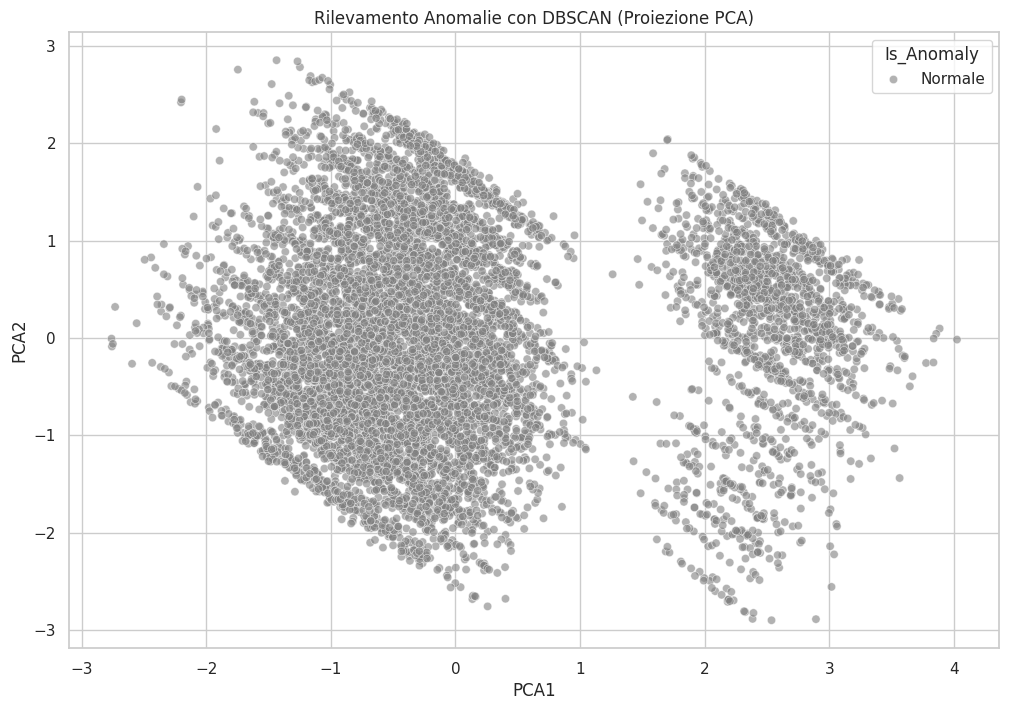

Esempi di studenti anomali:


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,Internship_Binary,Placement_Binary,Cluster_DBSCAN,Is_Anomaly,PCA1,PCA2


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# 1. Caricamento e Pre-processing
df = pd.read_csv('college_student_placement_dataset.csv')

# Convertiamo le stringhe in numeri
df['Internship_Binary'] = df['Internship_Experience'].map({'Yes': 1, 'No': 0})
df['Placement_Binary'] = df['Placement'].map({'Yes': 1, 'No': 0})

# Selezioniamo le features chiave per definire il comportamento dello studente
features = [
    'IQ', 'CGPA', 'Projects_Completed',
    'Internship_Binary', 'Placement_Binary', 'Communication_Skills'
]
X = df[features]

# 2. Standardizzazione (Cruciale per DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Applicazione DBSCAN
# eps: raggio massimo per considerare due punti vicini (trovato sperimentalmente)
# min_samples: numero minimo di punti per formare un cluster denso
dbscan = DBSCAN(eps=2.5, min_samples=12)
clusters = dbscan.fit_predict(X_scaled)

# DBSCAN etichetta gli outlier come -1
df['Cluster_DBSCAN'] = clusters
df['Is_Anomaly'] = df['Cluster_DBSCAN'].apply(lambda x: 'Anomalia' if x == -1 else 'Normale')

# 4. Analisi dei Risultati
n_anomalies = (df['Cluster_DBSCAN'] == -1).sum()
print(f"Numero di studenti anomali rilevati: {n_anomalies}")
print(f"Percentuale anomalie: {n_anomalies / len(df) * 100:.2f}%")

# Confrontiamo le anomalie con la media degli studenti normali
anomaly_profile = df.groupby('Is_Anomaly')[features].mean()
print("\nConfronto Profili (Medie):")
display(anomaly_profile)

# 5. Visualizzazione con PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df['PCA1'] = coords[:, 0]
df['PCA2'] = coords[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Is_Anomaly',
    style='Is_Anomaly',
    palette={'Normale': 'grey', 'Anomalia': 'red'},
    alpha=0.6,
    data=df
)
plt.title('Rilevamento Anomalie con DBSCAN (Proiezione PCA)')
plt.show()

# 6. Esempio di Anomalie (Chi sono?)
print("Esempi di studenti anomali:")
display(df[df['Is_Anomaly'] == 'Anomalia'].head())